In [6]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from preprocess import load_and_clean_data

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

In [7]:
# ================= DOMAIN LOGIC ===================
TYPE_RELATIONS = {
    "coffee shop": ["cafe", "tea shop", "bakery"],
    "restaurant": ["bar/pub", "vegetarian", "bakery"],
    "bar/pub": ["restaurant"],
    "natural": ["attraction", "entertainment"],
    "attraction": ["natural", "cultural", "historical"],
    "cultural": ["attraction", "historical"],
    "historical": ["attraction", "cultural"],
    "hotel": ["villa", "resort", "homestay", "hostel", "apartment"],
    "shopping": ["entertainment"],
    "entertainment": ["shopping", "natural"],
}


def calculate_similarity_score(user_type, poi_type):
    u = str(user_type).lower().strip()
    p = str(poi_type).lower().strip()

    if u == p:
        return 0.30
    if p in TYPE_RELATIONS.get(u, []):
        return 0.15
    return 0.0

In [8]:
# ================= BASE CLASS =====================
class BaseRecommender:
    def __init__(self, model_name="base"):
        self.model = None
        self.model_name = model_name
        self.encoders = {}

        self.cat_features = [
            "user_city",
            "user_type",
            "poi_city",
            "poi_type",
        ]

        self.num_features = [
            "user_price",
            "poi_price",
            "rating",
            "latitude",
            "longitude",
            "type_match_score",
        ]

        self.features = self.cat_features + self.num_features

    # -------- Feature Engineering ----------
    def feature_engineering(self, df):
        df = df.copy()

        df["type_match_score"] = df.apply(
            lambda x: calculate_similarity_score(x["user_type"], x["poi_type"]),
            axis=1,
        )

        for col in ["user_price", "poi_price", "rating"]:
            if col in df.columns:
                df[col] = df[col].fillna(0)

        return df

    # -------- Encoding---------------------
    def fit_encoders(self, df):
        for col in self.cat_features:
            le = LabelEncoder()
            df[col] = df[col].astype(str)
            df[col] = le.fit_transform(df[col])
            self.encoders[col] = le
        return df

    def transform_encoders(self, df):
        for col in self.cat_features:
            le = self.encoders[col]
            df[col] = df[col].astype(str).map(
                lambda s: le.transform([s])[0] if s in le.classes_ else -1
            )
        return df

    # -------- Train / Evaluate ---------------------
    def split_data(self, X, y):
        X_train, X_temp, y_train, y_temp = train_test_split(
            X, y, test_size=0.3, random_state=42
        )
        X_val, X_test, y_val, y_test = train_test_split(
            X_temp, y_temp, test_size=0.5, random_state=42
        )
        return X_train, X_val, X_test, y_train, y_val, y_test

    def train(self, df):
        raise NotImplementedError

    def evaluate(self, X_test, y_test):
        preds = self.model.predict(X_test)
        return {
            "MAE": mean_absolute_error(y_test, preds),
            "RMSE": root_mean_squared_error(y_test, preds),
            "R2": r2_score(y_test, preds),
        }

    # -------- Save / Load --------------------------
    def save(self, path):
        with open(path, "wb") as f:
            pickle.dump({"model": self.model, "encoders": self.encoders}, f)

    def load(self, path):
        with open(path, "rb") as f:
            payload = pickle.load(f)
        self.model = payload["model"]
        self.encoders = payload["encoders"]
        
    def recommend(self, df_raw, city, user_type, price, top_k=10):
        city = city.lower().strip()

        if isinstance(user_type, str):
            user_types = [user_type.lower().strip()]
        else:
            user_types = [ut.lower().strip() for ut in user_type]

        subset = df_raw[df_raw["city_norm"] == city]
        if subset.empty:
            return pd.DataFrame()

        rows = []
        for _, poi in subset.iterrows():
            for ut in user_types:
                rows.append({
                    "user_city": city,
                    "user_type": ut,
                    "user_price": price,
                    "poi_city": poi["city_norm"],
                    "poi_type": poi["type"],
                    "poi_price": poi["price_level"],
                    "rating": poi["rating"],
                    "latitude": poi["latitude"],
                    "longitude": poi["longitude"],
                    "poi_id": poi["poi_id"],
                    "name": poi["name"],
                })

        inf = pd.DataFrame(rows)

        # 1. Feature engineering (domain)
        inf = self.feature_engineering(inf)

        # 2. Encode đúng mapping lúc train
        inf = self.transform_encoders(inf)

        # 3. Predict
        inf["score"] = self.model.predict(inf[self.features])

        # 4. Aggregate & Top-K
        return (
            inf.groupby(["poi_id", "name"], as_index=False)["score"]
               .mean()
               .sort_values("score", ascending=False)
               .head(top_k)
        )

In [9]:
# ================= LINEAR BASELINE ================
class LinearRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(model_name="LinearRegression")

    def train(self, df):
        df = self.feature_engineering(df)
        df = self.fit_encoders(df)

        X = df[self.features]
        y = df["label"]

        X_train, X_val, X_test, y_train, y_val, y_test = self.split_data(X, y)

        self.model = LinearRegression()
        self.model.fit(X_train, y_train)

        # Validation (theo dõi)
        val_mae = mean_absolute_error(y_val, self.model.predict(X_val))

        # Test (đánh giá cuối cùng)
        test_metrics = self.evaluate(X_test, y_test)
        test_metrics["Val_MAE"] = val_mae

        return test_metrics



# ================= RANDOM FOREST ==================
class RandomForestRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(model_name="RandomForest")
        self.cat_feature_indices = [
            self.features.index(c)
            for c in self.cat_features
        ]

    def train(self, df):
        df = self.feature_engineering(df)
        df = self.fit_encoders(df)

        X = df[self.features]
        y = df["label"]

        X_train, X_val, X_test, y_train, y_val, y_test = self.split_data(X, y)

        self.model = RandomForestRegressor(
            n_estimators=300,
            max_depth=12,
            random_state=42,
            n_jobs=-1,
        )

        self.model.fit(X_train, y_train)

        val_mae = mean_absolute_error(y_val, self.model.predict(X_val))

        test_metrics = self.evaluate(X_test, y_test)
        test_metrics["Val_MAE"] = val_mae

        return test_metrics


# ================= CATBOOST (MAIN) ================
class CatBoostRecommender(BaseRecommender):
    def __init__(self):
        super().__init__(model_name="CatBoost")
        self.cat_features = ["user_city", "user_type", "poi_city", "poi_type"]

    def train(self, df):
        df = self.feature_engineering(df)

        for col in self.cat_features:
            df[col] = df[col].astype(str).fillna("unknown")

        X = df[self.features]
        y = df["label"]

        X_train, X_val, X_test, y_train, y_val, y_test = self.split_data(X, y)

        self.model = CatBoostRegressor(
            iterations=500,
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            eval_metric="MAE",
            verbose=False,
            allow_writing_files=False,
        )

        self.model.fit(
            X_train,
            y_train,
            cat_features=self.cat_features,
            eval_set=(X_val, y_val),
            use_best_model=True,
        )

        # Learning curve (validation MAE)
        self.learning_curve = (
            self.model.get_evals_result()["validation"]["MAE"]
        )

        return self.evaluate(X_test, y_test)
    
    def recommend(self, df_raw, city, user_type, price, top_k=10):
        city = city.lower().strip()

        if isinstance(user_type, str):
            user_types = [user_type.lower().strip()]
        else:
            user_types = [ut.lower().strip() for ut in user_type]

        subset = df_raw[df_raw["city_norm"] == city]
        if subset.empty:
            return pd.DataFrame()

        rows = []
        for _, poi in subset.iterrows():
            for ut in user_types:
                rows.append({
                    "user_city": city,
                    "user_type": ut,
                    "user_price": price,
                    "poi_city": poi["city_norm"],
                    "poi_type": poi["type"],
                    "poi_price": poi["price_level"],
                    "rating": poi["rating"],
                    "latitude": poi["latitude"],
                    "longitude": poi["longitude"],
                    "poi_id": poi["poi_id"],
                    "name": poi["name"],
                })

        inf = pd.DataFrame(rows)

        # Feature engineering ONLY
        inf = self.feature_engineering(inf)
        for col in self.cat_features:
            inf[col] = inf[col].astype(str).fillna("unknown")

        # Predict trực tiếp (raw categorical)
        inf["score"] = self.model.predict(inf[self.features])

        return (
            inf.groupby(["poi_id", "name"], as_index=False)["score"]
               .mean()
               .sort_values("score", ascending=False)
               .head(top_k)
        )
    
    def load(self, path):
        with open(path, "rb") as f:
            payload = pickle.load(f)
        self.model = payload["model"]



In [10]:
import pandas as pd

df = pd.read_csv("../data/recommender_training.csv")

models = [
    LinearRecommender(),
    RandomForestRecommender(),
    CatBoostRecommender(),
]

results = []

for m in models:
    metrics = m.train(df)
    metrics["Model"] = m.model_name
    results.append(metrics)

print(pd.DataFrame(results))


KeyError: "['poi_price'] not in index"

In [ ]:
linear = LinearRecommender()
linear.train(df)
linear.save("../models/linear_recommender.pkl")

In [ ]:
rf = RandomForestRecommender()
rf.train(df)
rf.save("../models/random_forest_recommender.pkl")

In [ ]:
cb = CatBoostRecommender()
cb.train(df)
cb.save("../models/catboost_recommender.pkl")

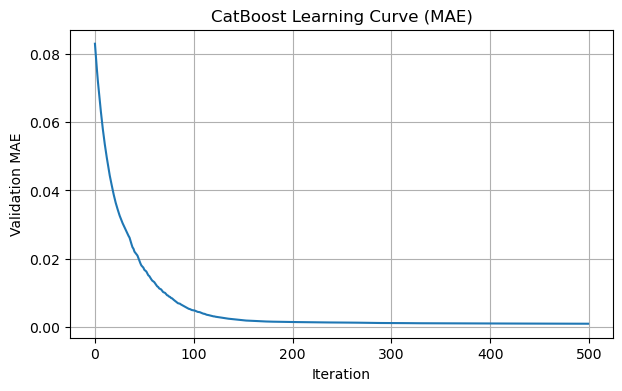

In [ ]:
def plot_learning_curve(cat_model):
    import matplotlib.pyplot as plt

    mae = cat_model.learning_curve
    plt.figure(figsize=(7, 4))
    plt.plot(mae)
    plt.xlabel("Iteration")
    plt.ylabel("Validation MAE")
    plt.title("CatBoost Learning Curve (MAE)")
    plt.grid(True)
    plt.show()

plot_learning_curve(cb)


In [ ]:
poi_df = load_and_clean_data("../data/POI.csv")

engine = CatBoostRecommender()
engine.load("../models/catboost_recommender.pkl")

top_poi = engine.recommend(
    df_raw=poi_df,
    city="da nang",
    user_type=["restaurant"],
    price=2,
    top_k=10
)

print(top_poi)


              poi_id                                               name  \
154  restaurant01232                                   Bếp Cuốn Đà Nẵng   
156  restaurant01238                                        Le Comptoir   
180  restaurant01699                                 Nhà Hàng Si Dining   
204  restaurant01723                  Pause and Enjoy Da Nang- 포즈 앤 엔조이   
179  restaurant01698                                   City High Dining   
196  restaurant01715                               Bon Bocon Restaurant   
184  restaurant01703                                   Ann Home Cuisine   
157  restaurant01239  Indus Indian Restaurant - Nhà hàng Ấn Độ - 인도 음식점   
169  restaurant01274                                Adobo Mexican Grill   
174  restaurant01284                        Cá Gỗ Vietnamese Restaurant   

        score  
154  0.996351  
156  0.996351  
180  0.996351  
204  0.995677  
179  0.994526  
196  0.994523  
184  0.993569  
157  0.993551  
169  0.993551  
174  0.993551 

In [ ]:
engine = LinearRecommender()
engine.load("../models/linear_recommender.pkl")

top_poi = engine.recommend(
    df_raw=poi_df,
    city="da nang",
    user_type=["restaurant"],
    price=2,
    top_k=10
)

print(top_poi)


              poi_id                               name     score
154  restaurant01232                   Bếp Cuốn Đà Nẵng  0.934570
156  restaurant01238                        Le Comptoir  0.934564
180  restaurant01699                 Nhà Hàng Si Dining  0.934553
196  restaurant01715               Bon Bocon Restaurant  0.932429
179  restaurant01698                   City High Dining  0.932415
202  restaurant01721         BaBaBa Japanese Restaurant  0.930304
155  restaurant01236                  The Nomad Kitchen  0.930303
165  restaurant01264  Gujarat Indian Restaurant Da nang  0.930303
162  restaurant01250       L'Italiano Restaurant Danang  0.930302
175  restaurant01286        ISH - The Indian Restaurant  0.930292


In [ ]:
engine = RandomForestRecommender()
engine.load("../models/random_forest_recommender.pkl")

top_poi = engine.recommend(
    df_raw=poi_df,
    city="da nang",
    user_type=["restaurant"],
    price=2,
    top_k=10
)

print(top_poi)


              poi_id                                               name  score
204  restaurant01723                  Pause and Enjoy Da Nang- 포즈 앤 엔조이  1.000
184  restaurant01703                                   Ann Home Cuisine  0.998
156  restaurant01238                                        Le Comptoir  0.998
169  restaurant01274                                Adobo Mexican Grill  0.998
199  restaurant01718                       Pistachio Restaurant Da Nang  0.998
180  restaurant01699                                 Nhà Hàng Si Dining  0.998
157  restaurant01239  Indus Indian Restaurant - Nhà hàng Ấn Độ - 인도 음식점  0.998
201  restaurant01720                                      Rainbowl Poke  0.998
154  restaurant01232                                   Bếp Cuốn Đà Nẵng  0.998
174  restaurant01284                        Cá Gỗ Vietnamese Restaurant  0.998
